In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.api import GLM, families
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm

In [2]:
#variables
variables = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="variables")
variables.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu,geometry
0,Aguas Frias,ALTAVISTA,32888.553485,1.308501e+07,27,13.085013,2.063429,3.472526,1.156317,0.332990,29.564836,5.118618,2.471720,0.000000,"MULTIPOLYGON (((4710927.69 2248217.723, 471092..."
1,Aldea Pablo VI,POPULAR,1548.983811,5.560887e+04,3,0.055609,53.948225,0.014758,0.128480,8.706006,19.185280,64.712141,0.000000,100.000000,"MULTIPOLYGON (((4718950.025 2253647.826, 47189..."
2,Alejandro Echavarría,BUENOS AIRES,3873.259719,3.600769e+05,15,0.360077,41.657774,0.095558,0.642398,6.722609,11.555980,62.817569,88.785759,11.039618,"MULTIPOLYGON (((4718344.177 2248210.468, 47183..."
3,Alejandría,EL POBLADO,2783.340991,4.314227e+05,8,0.431423,18.543298,0.114492,0.342612,2.992463,10.526186,46.877115,100.000000,0.000000,"MULTIPOLYGON (((4715894.965 2243436.368, 47158..."
4,Alfonso López,CASTILLA,3360.868167,3.679919e+05,2,0.367992,5.434902,0.097658,0.085653,0.877069,9.505469,73.895347,88.106810,0.000000,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [3]:
gdf = variables

In [4]:
gdf.describe()

,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu
count,348.000000,3.480000e+02,348.00000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,4884.195679,1.081193e+06,6.70977,1.082803,19.541674,0.286929,0.287356,3.153578,14.382395,55.448110,50.511041,9.272696
std,5357.950987,2.492141e+06,8.88117,2.492025,28.733296,0.661369,0.380350,4.636895,8.292821,28.882262,45.610183,26.981616
min,257.367765,2.754026e+03,0.00000,0.002754,0.000000,0.000731,0.000000,0.000000,1.683571,0.000000,0.000000,0.000000
25%,2510.848930,2.343425e+05,1.00000,0.234343,0.631789,0.062190,0.042827,0.101956,7.902588,32.525095,0.000000,0.000000
50%,3217.685757,3.705293e+05,3.50000,0.370529,8.709662,0.098332,0.149893,1.405540,13.408251,64.017833,53.665414,0.000000
75%,4357.636530,6.207013e+05,8.00000,0.621647,23.926065,0.164723,0.342612,3.861118,19.760685,80.164120,100.000000,0.000000
max,38723.006984,1.710786e+07,62.00000,17.107858,163.893433,4.540116,2.655246,26.448640,36.812111,95.820104,100.000000,100.000000


In [5]:
gdf["Log_Densidad"] = np.log1p(gdf["Densidad"])

In [6]:
n_barrios = len(gdf)

n_ceros = (gdf["Log_Densidad"] == 0).sum()

porcentaje = 100 * n_ceros / n_barrios

print(f"Barrios: {n_barrios}")
print(f"Barrios sin movimientos: {n_ceros}")
print(f"Porcentaje: {porcentaje:.1f}%")

Barrios: 348
Barrios sin movimientos: 70
Porcentaje: 20.1%


In [7]:
from scipy import stats

y = gdf["Log_Densidad"].astype(int).values

media = y.mean()
varianza = y.var(ddof=1)
idisp = varianza / media

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Índice de dispersión: {idisp:.2f}")

Media: 1.70
Varianza: 1.77
Índice de dispersión: 1.04


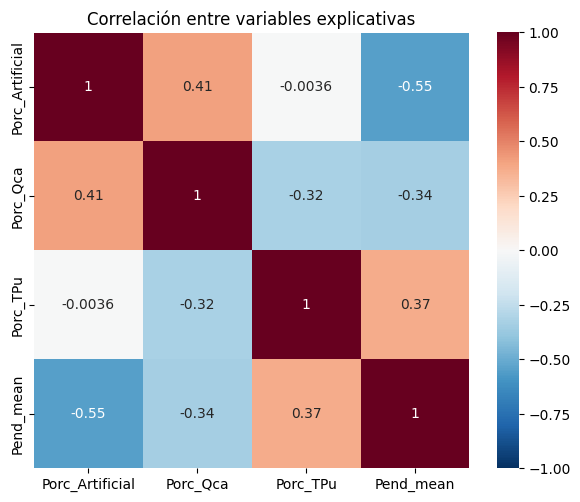

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Porc_Artificial","Porc_Qca", "Porc_TPu", "Pend_mean"]

corr = gdf[variables].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True)

plt.title("Correlación entre variables explicativas")
plt.tight_layout()
plt.show()

#Modelos de regresión espacial

In [9]:
from pysal.model import spreg
m1 = spreg.OLS(gdf[['Log_Densidad']].values, gdf[variables].values, name_y='Log_Densidad', name_x=variables)
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :Log_Densidad                Number of Observations:         348
Mean dependent var  :      2.1002                Number of Variables   :           5
S.D. dependent var  :      1.4811                Degrees of Freedom    :         343
R-squared           :      0.4843
Adjusted R-squared  :      0.4783
Sum squared residual:     392.547                F-statistic           :     80.5229
Sigma-square        :       1.144                Prob(F-statistic)     :   4.012e-48
S.E. of regression  :       1.070                Log likelihood        :    -514.749
Sigma-square ML     :       1.128                Akaike info criterion :    1039.499
S.E of regression ML:      1.0621                Schwarz criterion     :    1058.760

-----------------

###SAR

In [10]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

/usr/local/lib/python3.12/dist-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [11]:
knn5 = weights.KNN.from_dataframe(gdf, k=5)
knn5.transform = 'r'

In [12]:
wx = (
    gdf[variables]
    .apply(lambda columna: weights.lag_spatial(knn5, columna))
    .rename(columns=lambda nombre: "w_" + nombre))

In [13]:
wx.head()

,w_Porc_Artificial,w_Porc_Qca,w_Porc_TPu,w_Pend_mean
0,41.211859,1.407831,0.000000,23.122000
1,69.456922,16.666268,83.333732,25.005980
2,77.043979,65.650167,21.032533,15.867329
3,47.549054,78.420068,0.000000,8.504915
4,60.481719,68.803105,0.000000,8.477590


In [14]:
gdf = gdf.join(wx)

###SLX

In [15]:
slx_exog = gdf[variables].join(wx)
mslx = spreg.OLS(gdf[['Log_Densidad']].values, slx_exog.values, name_y='Log_Densidad',  name_x=slx_exog.columns.tolist())

print(mslx.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :Log_Densidad                Number of Observations:         348
Mean dependent var  :      2.1002                Number of Variables   :           9
S.D. dependent var  :      1.4811                Degrees of Freedom    :         339
R-squared           :      0.5576
Adjusted R-squared  :      0.5472
Sum squared residual:     336.708                F-statistic           :     53.4181
Sigma-square        :       0.993                Prob(F-statistic)     :   1.345e-55
S.E. of regression  :       0.997                Log likelihood        :    -488.051
Sigma-square ML     :       0.968                Akaike info criterion :     994.102
S.E of regression ML:      0.9836                Schwarz criterion     :    1028.772

-----------------

###Endogena con error

In [16]:
msem = spreg.GM_Error_Het(gdf[['Log_Densidad']].values, gdf[variables].values, w=knn5, name_y='Log_Densidad', name_x=variables)
print(msem.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Log_Densidad                Number of Observations:         348
Mean dependent var  :      2.1002                Number of Variables   :           5
S.D. dependent var  :      1.4811                Degrees of Freedom    :         343
Pseudo R-squared    :      0.4827
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.47563         0.37402        -1.27167         0.20349
     Porc_Artificia

###Endógena con variable dependiente

In [17]:
msar = spreg.GM_Lag(gdf[['Log_Densidad']].values, gdf[variables].values,
                     w=knn5, name_y='Log_Densidad', name_x=variables)
print(msar.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Log_Densidad                Number of Observations:         348
Mean dependent var  :      2.1002                Number of Variables   :           6
S.D. dependent var  :      1.4811                Degrees of Freedom    :         342
Pseudo R-squared    :      0.6364
Spatial Pseudo R-squared:  0.4975

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.80151         0.20927        -3.83000         0.00013
     Porc_Artificial         0.01263         0.00311         4.05381         0.00005
 

#Regimenes

In [18]:
from libpysal import weights

# Queen
wq = weights.Queen.from_dataframe(
    gdf,
    ids=gdf["nombre_bar"].tolist()
)

# KNN de 1 vecino
w_knn1 = weights.KNN.from_dataframe(
    gdf,
    k=1,
    ids=gdf["nombre_bar"].tolist()
)

# Unir ambas matrices
wq_conectada = weights.w_union(
    wq,
    w_knn1
)

wq_conectada.transform = "r"

print("Islas:", wq_conectada.islands)
print("Componentes:", wq_conectada.n_components)

Islas: []
Componentes: 1


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: Alejandro Echavarría.
  W.__init__(self, neighbors, ids=ids, **kw)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 92 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [19]:
from spopt.region import Skater
model = Skater(
    gdf,
    wq_conectada,
    attrs_name=variables,
    n_clusters=4
)

In [20]:
model.solve()

In [21]:
gdf["Region"] = model.labels_

In [22]:
print(gdf["Region"].value_counts().sort_index())

Region
0    137
1     30
2    163
3     18
Name: count, dtype: int64


In [23]:
import pandas as pd

variables = [
    "Movimientos",
    "Area_km2",
    "Densidad",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "Pend_mean"
]

tabla_regimenes = (
    gdf
    .groupby("Region")[variables]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

tabla_regimenes

Movimientos                              Area_km2                     \
             count   mean median    std min max    count  mean median   std   
Region                                                                        
0              137   4.13    1.0   7.01   0  34      137  1.88   0.48  3.46   
1               30  13.17    7.5  14.42   0  62       30  1.47   0.27  3.38   
2              163   8.04    5.0   8.57   0  41      163  0.39   0.32  0.39   
3               18   3.56    3.5   2.64   0   9       18  0.63   0.62  0.32   

        ... Porc_TPu                       Pend_mean                       \
        ...   median    std    min     max     count   mean median    std   
Region  ...                                                                 
0       ...      0.0   3.82   0.00   27.13       137  15.98  16.40  10.02   
1       ...    100.0  10.96  57.39  100.00        30  24.06  25.05   4.93   
2       ...      0.0   7.23   0.00   63.65       163  11.66  11.12   5.40   
3       ...      0.0   0.15   0.00    0.65        18  10.68  11.26   3.16   

                      
          min    max  
Region                
0        1.68  36.81  
1       10.44  30.95  
2        2.19  22.17  
3        5.72  16.61  

[4 rows x 42 columns]

In [25]:
from spreg import OLS_Regimes
variables = [
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "Pend_mean"]

# Variable respuesta
gdf["Densidad"] = (
    gdf["Movimientos"] /
    gdf["Area_km2"])

gdf["Log_Densidad"] = np.log1p(
    gdf["Densidad"])

columnas_modelo = [
    "Log_Densidad",
    "Region",
    *variables]

datos_reg = gdf.dropna(
    subset=columnas_modelo).copy()

y = datos_reg[["Log_Densidad"]].to_numpy()

X = datos_reg[variables].to_numpy()

regimenes = datos_reg["nombre_com"].to_numpy()

modelo_ols_reg = OLS_Regimes(
    y=y,
    x=X,
    regimes=regimenes,
    constant_regi="many",
    cols2regi="all",
    name_y="Log_Densidad",
    name_x=variables,
    name_regimes="Region",
    name_ds="Barrios de Medellín")

print(modelo_ols_reg.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES ESTIMATION - REGIME ALTAVISTA
------------------------------------------------------------------------------------
Data set            :Barrios de Medellín
Weights matrix      :        None
Dependent Variable  :ALTAVISTA_Log_Densidad                Number of Observations:          12
Mean dependent var  :      1.2111                Number of Variables   :           3
S.D. dependent var  :      1.2460                Degrees of Freedom    :           9
R-squared           :      0.2703
Adjusted R-squared  :      0.1081
Sum squared residual:      12.462                F-statistic           :      1.6668
Sigma-square        :       1.385                Prob(F-statistic)     :      0.2422
S.E. of regression  :       1.177                Log likelihood        :     -17.254
Sigma-square ML     :       1.038                Akaike info criterion :      40.508
S.E of regression ML:      1.0191                Schwarz

In [26]:
print(modelo_ols_reg.chow)

In [27]:
from spreg import ML_Lag_Regimes

modelo_sar_reg = ML_Lag_Regimes(
    y=y,
    x=X,
    regimes=regimenes,
    w=wq_conectada,
    constant_regi="many",
    cols2regi="all",
    regime_lag_sep=False,
    method="ord",
    spat_diag=True,
    spat_impacts="full",
    name_y="Log_Densidad",
    name_x=variables,
    name_w="Queen conectada",
    name_regimes="Region",
    name_ds="Barrios de Medellín"
)

print(modelo_sar_reg.summary)

LinAlgError: Singular matrix

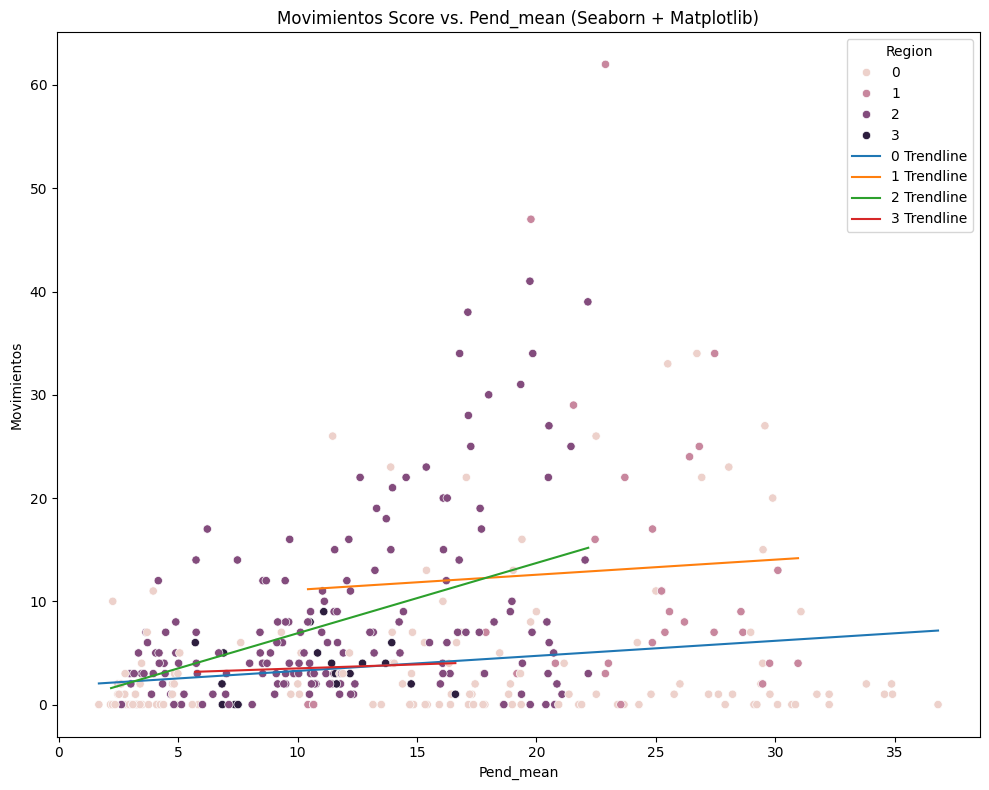

In [28]:
import statsmodels.api as sm
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf, x="Pend_mean", y="Movimientos", hue="Region")

# Fit and plot separate trendlines for each group
groups = gdf["Region"].unique()
for group in groups:
    group_data = gdf[gdf["Region"] == group]
    X = group_data["Pend_mean"]
    y = group_data["Movimientos"]
    # Fit linear model
    X = sm.add_constant(X)  # Add constant for intercept
    model = sm.OLS(y, X).fit()
    # Plot the trendline
    trend_x = np.linspace(group_data["Pend_mean"].min(), group_data["Pend_mean"].max(), 100)
    trend_y = model.predict(sm.add_constant(trend_x))
    plt.plot(trend_x, trend_y, label=f"{group} Trendline")

# Customize plot
plt.title("Movimientos Score vs. Pend_mean (Seaborn + Matplotlib)")
plt.xlabel("Pend_mean")
plt.ylabel("Movimientos")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

In [ ]:
from spreg import ML_Lag_Regimes

In [29]:
variables = [
   "Porc_Artificial",
   "Pend_mean"
    #"Porc_Qca",
   # "Porc_TPu",
    ]

y = gdf[["Log_Densidad"]].values

X = gdf[variables].values

regimenes = gdf["Region"].values

w = wq_conectada
w.transform = "r"

In [30]:
modelo_sar_reg = ML_Lag_Regimes(
    y=y,
    x=X,
    regimes=regimenes,
    w=w,

    constant_regi="many",
    cols2regi="all",

    regime_lag_sep=False,

    method="ord",

    spat_diag=True,

    name_y="Log_Densidad",
    name_x=variables,
    name_w="Queen",
    name_regimes="Region",
    name_ds="Movimientos"
)

print(modelo_sar_reg.summary)

ML_Lag_Regimes
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG - REGIMES (METHOD = ord)
------------------------------------------------------------------------------------
Data set            : Movimientos
Weights matrix      :       Queen
Dependent Variable  :Log_Densidad                Number of Observations:         348
Mean dependent var  :      2.1002                Number of Variables   :          13
S.D. dependent var  :      1.4811                Degrees of Freedom    :         335
Pseudo R-squared    :      0.6317
Spatial Pseudo R-squared:  0.5426
Log likelihood      :   -469.8017
Sigma-square ML     :      0.8094                Akaike info criterion :     965.603
S.E of regression   :      0.8997                Schwarz criterion     :    1015.682

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
--------------------